In [4]:
import pandas as pd
import geopandas as gpd
import json
from functools import partial
from tqdm import tqdm

import matplotlib.pyplot as plt

import nomad.io.base as loader
import nomad.stop_detection.utils as utils
from nomad.stop_detection.density_based import seqscan_labels
from nomad.stop_detection.dbscan import ta_dbscan_labels

import nomad.visit_attribution.visit_attribution as visits

from nomad.stop_detection.validation import (
    AlgorithmRegistry,
    compute_stop_detection_metrics,
    plot_metric_vs_param,
 )
import warnings
warnings.filterwarnings('ignore', message='Input is timezone-naive; assuming UTC')

## Load Files

In [5]:
key = '2_stops'
with open(f'config_{key}.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

out = config['output_files']

poi_table = gpd.read_parquet(config['buildings_file']).rename(columns={'id': 'location'})
sparse_df = loader.from_file(out['sparse_path'], format='parquet')
sparse_df.drop(columns=['datetime'], inplace=True)
diaries_df = loader.from_file(out['diaries_path'], format='parquet').rename(
    columns={'identifier': 'user_id'})
poi_subset = poi_table.loc[poi_table.location.isin(diaries_df['location'].dropna())]

# R stores all parameterized algorithm runs and can be iterated directly in execution.
R = AlgorithmRegistry()
R.add_algorithm(
    seqscan_labels,
    family='seqscan',
    granularity=10,
    time_thresh=60,
    dist_thresh=(6, 25),
    min_pts=2,
    back_merge=False,
    x='x',
    y='y',
    timestamp='timestamp',
)
R.add_algorithm(
    ta_dbscan_labels,
    family='st_dbscan',
    granularity=10,
    time_thresh=60,
    dist_thresh=(6, 25),
    min_pts=2,
    x='x',
    y='y',
    timestamp='timestamp',
)

summarize_stops_with_loc = partial(
    utils.summarize_stop,
    x='x',
    y='y',
    timestamp='timestamp',
    keep_col_names=True,
    passthrough_cols=['location'],
    complete_output=False)

## Execution of stop detection

In [6]:
results_list = []
users = diaries_df.user_id.unique()

sparse_df['precomp_locations'] = visits.poi_map(
    sparse_df,
    poi_table=poi_subset,
    data_crs='EPSG:3857',
    max_distance=20,
    location_id='location',
    x='x',
    y='y',
)

for algo in tqdm(R, desc='Processing algorithms'):
    for user in users:
        sparse = sparse_df.query("user_id==@user").copy()
        truth = diaries_df.query("user_id==@user").copy()

        labels = R.time_call(algo, sparse)
        sparse['cluster'] = labels
        sparse['location'] = sparse['precomp_locations']

        sparse['location'] = visits.point_in_polygon(
            sparse,
            poi_table=poi_subset,
            method='majority',
            location_id='location',
            recompute_location=False,
            x='x',
            y='y',
        )

        stops = sparse[sparse.cluster != -1].groupby('cluster', as_index=False).apply(
            summarize_stops_with_loc, include_groups=False)

        metrics = compute_stop_detection_metrics(
            stops=stops,
            truth=truth,
            user_id=user,
            algorithm=algo['algorithm'],
            traj_cols={'location_id': 'location'},
            timestamp='timestamp',
        )

        results_list.append(R.annotate_metrics(metrics, algo))

results_df = pd.DataFrame(results_list)
timing_summary = R.family_timing_summary()

timing_summary

Processing algorithms: 100%|██████████| 20/20 [02:45<00:00,  8.29s/it]


,family,n,mean_s,std_s,min_s,max_s
1,st_dbscan,2500,0.005850,0.002798,0.001775,0.090606
0,seqscan,2500,0.016241,0.006535,0.004589,0.082148


# Plotting

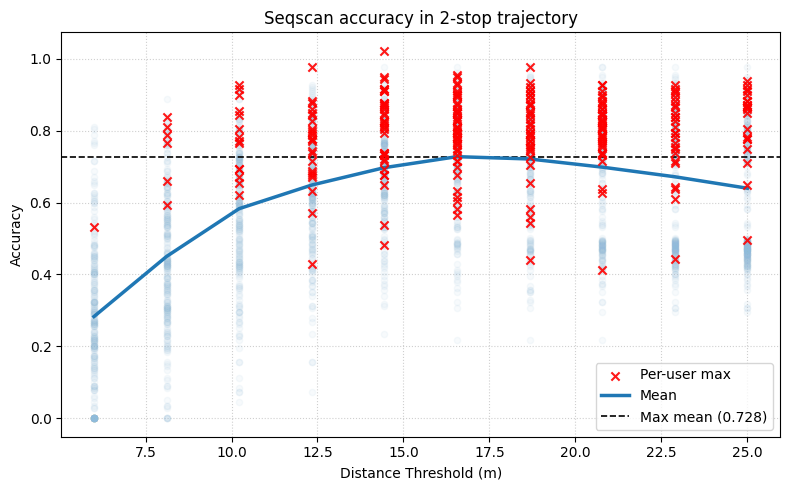

In [7]:
# Seqscan
fig, ax = plt.subplots(figsize=(8, 5))
plot_metric_vs_param(
    ax=ax,
    data=results_df.query("family == 'seqscan'"),
    x='dist_thresh',
    y='recall',
    algo_param='dist_thresh',
    show_max_mean_line=True,
    title='Seqscan accuracy in 2-stop trajectory',
    xlabel='Distance Threshold (m)',
    ylabel='Accuracy',
)
fig.tight_layout()
plt.savefig('figures/seqscan_dist_thresh_acc.svg', bbox_inches='tight')
plt.savefig('figures/seqscan_dist_thresh_acc.png', dpi=600, bbox_inches='tight')
plt.show()

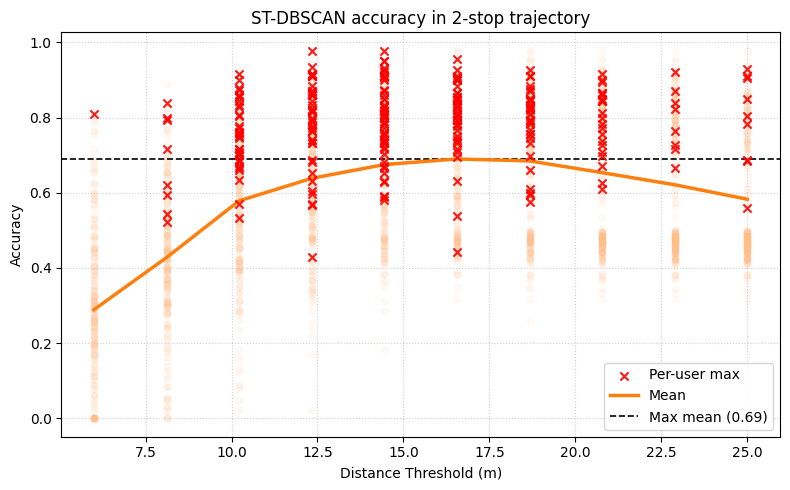

In [8]:
# ST-DBSCAN
fig, ax = plt.subplots(figsize=(8, 5))
plot_metric_vs_param(
    ax=ax,
    data=results_df.query("family == 'st_dbscan'"),
    x='dist_thresh',
    y='recall',
    algo_param='dist_thresh',
    show_max_mean_line=True,
    title='ST-DBSCAN accuracy in 2-stop trajectory',
    xlabel='Distance Threshold (m)',
    ylabel='Accuracy',
    color='C1',
)
fig.tight_layout()
plt.savefig('figures/st_dbscan_dist_thresh_acc.svg', bbox_inches='tight')
plt.savefig('figures/st_dbscan_dist_thresh_acc.png', dpi=600, bbox_inches='tight')
plt.show()

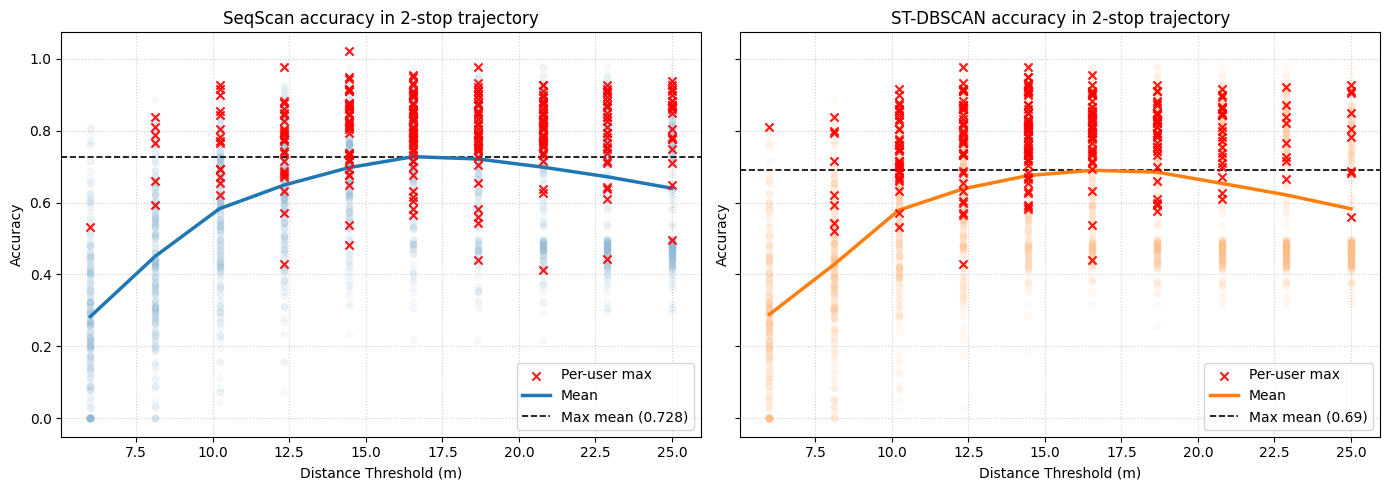

In [9]:
# Combined
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_metric_vs_param(
    ax=axes[0],
    data=results_df.query("family == 'seqscan'"),
    x='dist_thresh',
    y='recall',
    algo_param='dist_thresh',
    show_max_mean_line=True,
    title='SeqScan accuracy in 2-stop trajectory',
    xlabel='Distance Threshold (m)',
    ylabel='Accuracy',
)
plot_metric_vs_param(
    ax=axes[1],
    data=results_df.query("family == 'st_dbscan'"),
    x='dist_thresh',
    y='recall',
    algo_param='dist_thresh',
    show_max_mean_line=True,
    title='ST-DBSCAN accuracy in 2-stop trajectory',
    xlabel='Distance Threshold (m)',
    ylabel='Accuracy',
    color='C1',
)
fig.tight_layout()
fig.savefig('figures/dist_thresh_acc_combined.svg', bbox_inches='tight')
fig.savefig('figures/dist_thresh_acc_combined.png', dpi=600, bbox_inches='tight')
plt.show()